In [12]:
import seaborn as sns
import pandas as pd
import json
from pathlib import Path
from matplotlib.patches import Ellipse
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [13]:
result_path = Path("../results/downstream_task")
bias_type = "less_positive_class"
less_bias_strength = "0.1"
method = "fw-mrs-temperature-comparison"
data_set_name = "folktables_income"

In [14]:
dropped_samples_file_name = result_path / data_set_name / bias_type / less_bias_strength / method / "validation" / "dropped_samples_individual_val_dict.json"
with open(dropped_samples_file_name) as file:
        dropped_samples = json.load(file)
        dropped_samples = pd.DataFrame(dropped_samples)
auroc_file_name = result_path / data_set_name / bias_type / less_bias_strength / method / "validation" / "auroc_individual_val_dict.json"
with open(auroc_file_name) as file:
        aurocs = json.load(file)
        aurocs = pd.DataFrame(aurocs)

In [15]:
aurocs

,0.5,0.25,0.1,0.05,0.025,0.01,0.005,0.0025,0.001,0.0
0,0.833599,0.833556,0.831408,0.82327,0.81063,0.783523,0.77015,0.748993,0.729427,0.837557


In [16]:
temperatures = dropped_samples.keys().astype(float)
temperatures

Index([0.5, 0.25, 0.1, 0.05, 0.025, 0.01, 0.005, 0.0025, 0.001, 0.0], dtype='float64')

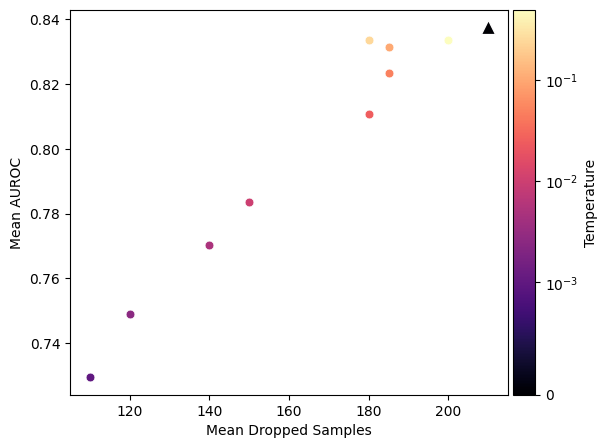

In [17]:
cmap = sns.color_palette("magma", as_cmap=True)
norm = matplotlib.colors.SymLogNorm(linthresh=0.001, vmin=np.min(temperatures), vmax=np.max(temperatures))
fig = plt.figure(figsize=(6,5))
mrs_value = 0.0

for key, dropped_value in dropped_samples[temperatures.astype(str)].items():
    auroc_value = aurocs[key]
    if float(key) == mrs_value:
        marker= "^"
        size= 100
    else: 
        marker = "o"
        size= 40
        
    color = cmap(norm(float(key)))
    ax = sns.scatterplot(x=[dropped_value.mean()], y=[auroc_value.mean()], label=key, alpha=1, color=color, marker=marker,
                         s=size, )
    ellipse = Ellipse((dropped_value.mean(), auroc_value.mean()),
                       width=2*dropped_value.std(), height=2*auroc_value.std(), alpha=0.5,
                       color=color)
    ax.add_patch(ellipse)

plt.gca().legend_.remove()

divider = make_axes_locatable(plt.gca())
ax_cb = divider.new_horizontal(size="5%", pad=0.05)
fig.add_axes(ax_cb)
cb1 = matplotlib.colorbar.ColorbarBase(ax_cb, cmap=cmap,
                                norm=norm,
                                orientation='vertical')
cb1.set_label('Temperature')

_= ax.set(xlabel="Mean Dropped Samples", ylabel="Mean AUROC")

In [18]:
dropped_samples_file_name = result_path / data_set_name / bias_type / less_bias_strength / method / "validation" / "dropped_samples_val_dict.json"
with open(dropped_samples_file_name) as file:
        dropped_samples = json.load(file)
        dropped_samples = pd.DataFrame(dropped_samples)
auroc_file_name = result_path / data_set_name / bias_type / less_bias_strength / method / "validation" / "auroc_val_dict.json"
with open(auroc_file_name) as file:
        aurocs = json.load(file)
        aurocs = pd.DataFrame(aurocs)

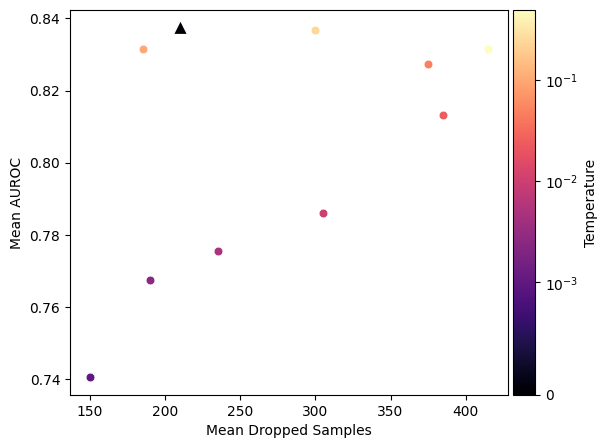

In [19]:
cmap = sns.color_palette("magma", as_cmap=True)
norm = matplotlib.colors.SymLogNorm(linthresh=0.001, vmin=np.min(temperatures), vmax=np.max(temperatures))
fig = plt.figure(figsize=(6,5))
mrs_value = 0.0

for key, dropped_value in dropped_samples[temperatures.astype(str)].items():
    auroc_value = aurocs[key]
    if float(key) == mrs_value:
        marker= "^"
        size= 100
    else: 
        marker = "o"
        size= 40
        
    color = cmap(norm(float(key)))
    ax = sns.scatterplot(x=[dropped_value.mean()], y=[auroc_value.mean()], label=key, alpha=1, color=color, marker=marker,
                         s=size, )
    ellipse = Ellipse((dropped_value.mean(), auroc_value.mean()),
                       width=2*dropped_value.std(), height=2*auroc_value.std(), alpha=0.5,
                       color=color)
    ax.add_patch(ellipse)

plt.gca().legend_.remove()

divider = make_axes_locatable(plt.gca())
ax_cb = divider.new_horizontal(size="5%", pad=0.05)
fig.add_axes(ax_cb)
cb1 = matplotlib.colorbar.ColorbarBase(ax_cb, cmap=cmap,
                                norm=norm,
                                orientation='vertical')
cb1.set_label('Temperature')

_= ax.set(xlabel="Mean Dropped Samples", ylabel="Mean AUROC")